# S&P 500 Clustering Pipeline
Single notebook with feature-case tuning, **k selection**, and temporal stability evaluation (train → validation → test).

## 1. Setup

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

## 2. Load Data

In [14]:
csv_path = "data/sp500_5yr_with_sectors_weights.csv"

df = pd.read_csv(csv_path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Symbol', 'Date']).copy()

print("Min date:", df['Date'].min())
print("Max date:", df['Date'].max())
print("Rows:", len(df))
print("Stocks:", df['Symbol'].nunique())
df.head()

Min date: 2021-03-22 00:00:00
Max date: 2026-03-20 00:00:00
Rows: 626169
Stocks: 503


,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,Weight
11304,2021-03-22,118.071328,119.675641,117.636428,119.463020,1772900,A,Agilent Technologies,Health Care,0.0005
11305,2021-03-23,119.018449,120.062218,117.394811,117.887703,1338300,A,Agilent Technologies,Health Care,0.0005
11306,2021-03-24,118.022998,118.834813,116.689291,116.785934,1477500,A,Agilent Technologies,Health Care,0.0005
11307,2021-03-25,116.805284,118.225969,115.858159,117.810394,967300,A,Agilent Technologies,Health Care,0.0005
11308,2021-03-26,118.428900,121.492548,117.936008,121.424896,1441900,A,Agilent Technologies,Health Care,0.0005


## 3. Time-based Split (3y / 1y / 1y)

In [15]:
train = df[(df['Date'] >= '2021-03-22') & (df['Date'] <= '2024-03-21')].copy()
val   = df[(df['Date'] >= '2024-03-22') & (df['Date'] <= '2025-03-21')].copy()
test  = df[(df['Date'] >= '2025-03-22') & (df['Date'] <= '2026-03-21')].copy()

print("Train rows:", len(train))
print("Validation rows:", len(val))
print("Test rows:", len(test))

Train rows: 375299
Validation rows: 125271
Test rows: 125599


## 4. Keep Only Stocks Available in All 3 Splits

In [16]:
common_symbols = (
    set(train['Symbol'].unique())
    & set(val['Symbol'].unique())
    & set(test['Symbol'].unique())
)

train = train[train['Symbol'].isin(common_symbols)].copy()
val   = val[val['Symbol'].isin(common_symbols)].copy()
test  = test[test['Symbol'].isin(common_symbols)].copy()

print("Common stocks:", len(common_symbols))
print("Train stocks:", train['Symbol'].nunique())
print("Validation stocks:", val['Symbol'].nunique())
print("Test stocks:", test['Symbol'].nunique())

Common stocks: 499
Train stocks: 499
Validation stocks: 499
Test stocks: 499


## 5. Feature Engineering

In [17]:
def create_features(df):
    df = df.copy()
    df['log_close'] = np.log(df['Close'])

    # Returns
    df['logret_1'] = df.groupby('Symbol')['log_close'].diff(1)
    df['logret_5'] = df.groupby('Symbol')['log_close'].diff(5)
    df['logret_21'] = df.groupby('Symbol')['log_close'].diff(21)

    # Matched volatility windows
    df['logvol_1'] = df.groupby('Symbol')['logret_1'].rolling(2).std().reset_index(level=0, drop=True)
    df['logvol_5'] = df.groupby('Symbol')['logret_1'].rolling(5).std().reset_index(level=0, drop=True)
    df['logvol_21'] = df.groupby('Symbol')['logret_1'].rolling(21).std().reset_index(level=0, drop=True)

    # Volume feature
    df['log_volume'] = np.log(df['Volume'].clip(lower=1))
    df['vol_chg'] = df.groupby('Symbol')['log_volume'].diff()

    return df

train = create_features(train)
val   = create_features(val)
test  = create_features(test)

train.head()

,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,Weight,log_close,logret_1,logret_5,logret_21,logvol_1,logvol_5,logvol_21,log_volume,vol_chg
11304,2021-03-22,118.071328,119.675641,117.636428,119.463020,1772900,A,Agilent Technologies,Health Care,0.0005,4.783007,NaN,NaN,NaN,NaN,NaN,NaN,14.388127,NaN
11305,2021-03-23,119.018449,120.062218,117.394811,117.887703,1338300,A,Agilent Technologies,Health Care,0.0005,4.769733,-0.013274,NaN,NaN,NaN,NaN,NaN,14.106911,-0.281216
11306,2021-03-24,118.022998,118.834813,116.689291,116.785934,1477500,A,Agilent Technologies,Health Care,0.0005,4.760343,-0.009390,NaN,NaN,0.002747,NaN,NaN,14.205862,0.098951
11307,2021-03-25,116.805284,118.225969,115.858159,117.810394,967300,A,Agilent Technologies,Health Care,0.0005,4.769077,0.008734,NaN,NaN,0.012815,NaN,NaN,13.782264,-0.423598
11308,2021-03-26,118.428900,121.492548,117.936008,121.424896,1441900,A,Agilent Technologies,Health Care,0.0005,4.799296,0.030219,NaN,NaN,0.015193,NaN,NaN,14.181472,0.399208


## 6. Define Feature Cases

In [18]:
FEATURE_CASES = {
    "case_1": ['logret_1', 'logvol_1', 'vol_chg'],
    "case_2": ['logret_5', 'logvol_5', 'vol_chg'],
    "case_3": ['logret_21', 'logvol_21', 'vol_chg']
}

FEATURE_CASES

{'case_1': ['logret_1', 'logvol_1', 'vol_chg'],
 'case_2': ['logret_5', 'logvol_5', 'vol_chg'],
 'case_3': ['logret_21', 'logvol_21', 'vol_chg']}

## 7. Aggregate Daily Features to One Vector Per Stock

In [19]:
def aggregate_features(df, feature_cols):
    X = df.groupby('Symbol')[feature_cols].mean()
    return X.dropna()

## 8. KMeans Helper Functions

In [20]:
def fit_kmeans(X, k):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    return model, scaler, labels, score, X_scaled

def apply_kmeans(X, model, scaler):
    X_scaled = scaler.transform(X)
    labels = model.predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    return labels, score, X_scaled

def evaluate_k_range(X, k_range=range(2, 9)):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    rows = []
    for k in k_range:
        model = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = model.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        inertia = model.inertia_

        rows.append({
            "k": k,
            "silhouette": sil,
            "inertia": inertia
        })

    return pd.DataFrame(rows), X_scaled

## 9. Compare Feature Cases on Training Set
For a fair comparison, each feature case is evaluated over the same candidate k values, and we keep the **best silhouette** achieved by that case.

In [21]:
feature_case_results = []

for case_name, feature_cols in FEATURE_CASES.items():
    X_train_case = aggregate_features(train, feature_cols)
    k_results_case, _ = evaluate_k_range(X_train_case, k_range=range(2, 9))

    best_idx = k_results_case['silhouette'].idxmax()
    best_k_case = int(k_results_case.loc[best_idx, 'k'])
    best_sil_case = float(k_results_case.loc[best_idx, 'silhouette'])

    feature_case_results.append({
        "case": case_name,
        "features": ", ".join(feature_cols),
        "n_stocks": len(X_train_case),
        "best_k": best_k_case,
        "best_train_silhouette": best_sil_case
    })

feature_case_results_df = (
    pd.DataFrame(feature_case_results)
    .sort_values("best_train_silhouette", ascending=False)
    .reset_index(drop=True)
)

feature_case_results_df

,case,features,n_stocks,best_k,best_train_silhouette
0,case_1,"logret_1, logvol_1, vol_chg, Weight",499,2,0.711235
1,case_3,"logret_21, logvol_21, vol_chg, Weight",499,2,0.710835
2,case_2,"logret_5, logvol_5, vol_chg, Weight",499,2,0.710562


## 10. Select Best Feature Case

In [22]:
best_case = feature_case_results_df.loc[0, 'case']
best_features = FEATURE_CASES[best_case]

print("Best feature case:", best_case)
print("Selected features:", best_features)

Best feature case: case_1
Selected features: ['logret_1', 'logvol_1', 'vol_chg']


## 11. Select the Number of Clusters (k)
Use **silhouette score** as the main criterion and **inertia** as supporting evidence.

In [23]:
X_train = aggregate_features(train, best_features)

k_results, X_train_scaled_for_k = evaluate_k_range(X_train, k_range=range(2, 9))
k_results

,k,silhouette,inertia
0,2,0.711235,1612.375606
1,3,0.376917,1304.150250
2,4,0.311609,1100.987918
3,5,0.291303,934.407915
4,6,0.236536,801.974036
5,7,0.214508,743.343370
6,8,0.217378,674.930865


## 12. Plot Silhouette and Elbow Curves

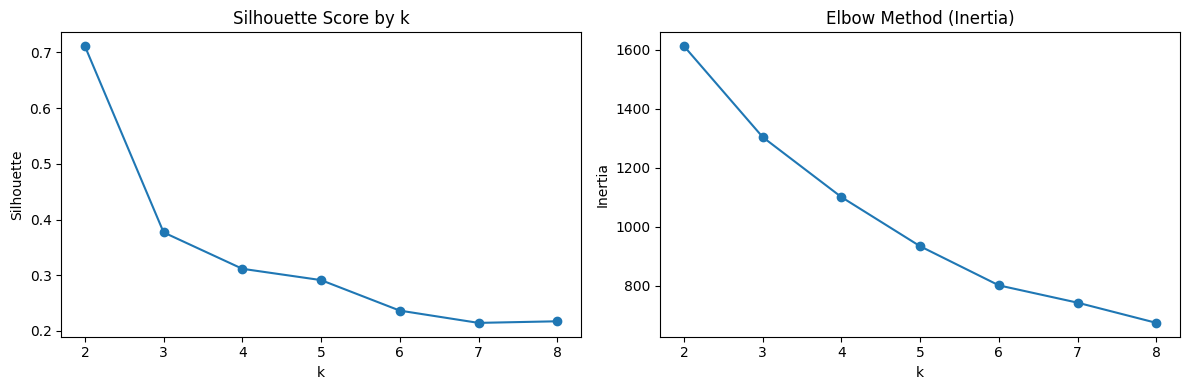

In [24]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_results['k'], k_results['silhouette'], marker='o')
plt.title("Silhouette Score by k")
plt.xlabel("k")
plt.ylabel("Silhouette")

plt.subplot(1, 2, 2)
plt.plot(k_results['k'], k_results['inertia'], marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("k")
plt.ylabel("Inertia")

plt.tight_layout()
plt.show()

## 13. Choose Best k

In [25]:
best_k = int(k_results.loc[k_results['silhouette'].idxmax(), 'k'])
print("Selected k:", best_k)

Selected k: 2


## 14. Fit Final Clustering on Train

In [26]:
model, scaler, train_labels, train_score, X_train_scaled = fit_kmeans(X_train, k=best_k)

train_clusters = pd.DataFrame({
    "Symbol": X_train.index,
    "Cluster_train": train_labels
})

print("Train silhouette:", round(train_score, 4))
train_clusters.head()

Train silhouette: 0.7112


,Symbol,Cluster_train
0,A,0
1,AAPL,1
2,ABBV,0
3,ABNB,0
4,ABT,0


## 15. Evaluate Cluster Stability on Validation

In [27]:
X_val = aggregate_features(val, best_features)

common_train_val = X_train.index.intersection(X_val.index)
X_val = X_val.loc[common_train_val]

val_labels, val_score, X_val_scaled = apply_kmeans(X_val, model, scaler)

val_clusters = pd.DataFrame({
    "Symbol": X_val.index,
    "Cluster_val": val_labels
})

print("Validation silhouette:", round(val_score, 4))
val_clusters.head()

Validation silhouette: 0.5125


,Symbol,Cluster_val
0,A,0
1,AAPL,1
2,ABBV,0
3,ABNB,0
4,ABT,0


## 16. Confirm Cluster Stability on Test

In [28]:
X_test = aggregate_features(test, best_features)

common_train_test = X_train.index.intersection(X_test.index)
X_test = X_test.loc[common_train_test]

test_labels, test_score, X_test_scaled = apply_kmeans(X_test, model, scaler)

test_clusters = pd.DataFrame({
    "Symbol": X_test.index,
    "Cluster_test": test_labels
})

print("Test silhouette:", round(test_score, 4))
test_clusters.head()

Test silhouette: 0.457


,Symbol,Cluster_test
0,A,0
1,AAPL,1
2,ABBV,0
3,ABNB,0
4,ABT,0


## 17. Stability Summary

In [29]:
stability_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "silhouette": [train_score, val_score, test_score]
})

stability_summary

,split,silhouette
0,train,0.711235
1,validation,0.512503
2,test,0.456959


## 18. Same-Stock Cluster Consistency

In [30]:
train_val_compare = train_clusters.merge(val_clusters, on="Symbol", how="inner")
train_test_compare = train_clusters.merge(test_clusters, on="Symbol", how="inner")

train_val_consistency = (train_val_compare["Cluster_train"] == train_val_compare["Cluster_val"]).mean()
train_test_consistency = (train_test_compare["Cluster_train"] == train_test_compare["Cluster_test"]).mean()

print("Train vs Validation consistency:", round(train_val_consistency, 4))
print("Train vs Test consistency:", round(train_test_consistency, 4))

Train vs Validation consistency: 1.0
Train vs Test consistency: 1.0


## 19. Cluster Profiles on Training Set

In [31]:
train_profile = X_train.copy()
train_profile["Cluster"] = train_labels

cluster_profile = train_profile.groupby("Cluster").mean()
cluster_profile

,logret_1,logvol_1,vol_chg,Weight
Cluster,,,,
0,0.000338,0.014234,-0.000021,0.001307
1,0.000767,0.017932,-0.000324,0.039333


## 20. PCA Visualization of Training Clusters

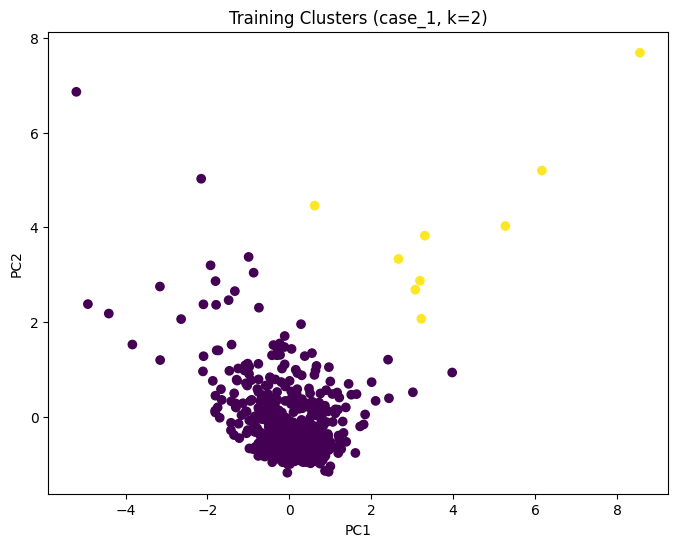

In [32]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=train_labels)
plt.title(f"Training Clusters ({best_case}, k={best_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [35]:
pd.Series(train_labels).value_counts()

0    490
1      9
Name: count, dtype: int64

## 21. Final Cluster Assignment Table

In [33]:
final_clusters = (
    train_clusters
    .merge(val_clusters, on="Symbol", how="left")
    .merge(test_clusters, on="Symbol", how="left")
)

final_clusters.head()

,Symbol,Cluster_train,Cluster_val,Cluster_test
0,A,0,0,0
1,AAPL,1,1,1
2,ABBV,0,0,0
3,ABNB,0,0,0
4,ABT,0,0,0


## 22. Optional Export

In [34]:
# Uncomment if you want to save outputs
# feature_case_results_df.to_csv("feature_case_results.csv", index=False)
# k_results.to_csv("k_selection_results.csv", index=False)
# stability_summary.to_csv("cluster_stability_summary.csv", index=False)
# cluster_profile.to_csv("cluster_profile.csv")
# final_clusters.to_csv("final_cluster_assignments.csv", index=False)

In [36]:
val = val.copy()

val['future_vol_21'] = (
    val.groupby('Symbol')['logret_1']
    .rolling(21)
    .std()
    .shift(-21)
    .reset_index(level=0, drop=True)
)

val = val.dropna(subset=['future_vol_21'])

In [37]:
# Merge cluster labels back
cluster_map = train_clusters.set_index("Symbol")

val_eval = val.copy()
val_eval = val_eval.merge(cluster_map, left_on="Symbol", right_index=True)

# Compare future volatility
val_eval.groupby("Cluster_train")['future_vol_21'].mean()

Cluster_train
0    0.017287
1    0.023307
Name: future_vol_21, dtype: float64

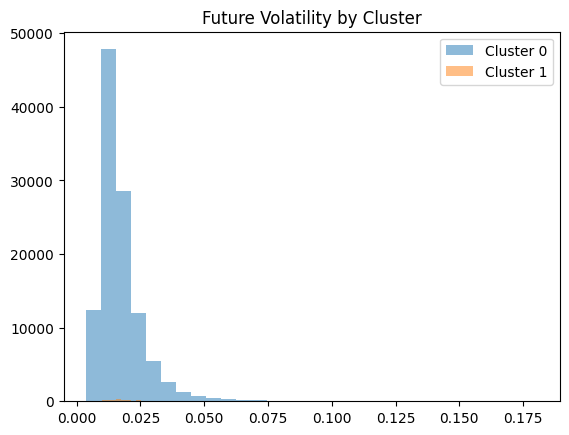

In [38]:
import matplotlib.pyplot as plt

for c in val_eval['Cluster_train'].unique():
    subset = val_eval[val_eval['Cluster_train'] == c]
    plt.hist(subset['future_vol_21'], bins=30, alpha=0.5, label=f'Cluster {c}')

plt.legend()
plt.title("Future Volatility by Cluster")
plt.show()

## 23. Cluster Profile Interpretation


In [ ]:
# Compare cluster means in raw units and z-scores (train split)
train_profile_detail = X_train.copy()
train_profile_detail["Cluster"] = train_labels

cluster_profile_mean = train_profile_detail.groupby("Cluster")[best_features].mean()
overall_mean = X_train[best_features].mean()
overall_std = X_train[best_features].std(ddof=0).replace(0, np.nan)
cluster_profile_z = (cluster_profile_mean - overall_mean) / overall_std

print("Cluster profile: means")
display(cluster_profile_mean.round(4))

print("Cluster profile: z-score vs full train universe")
display(cluster_profile_z.round(3))

if cluster_profile_mean.shape[0] == 2:
    abs_diff = (cluster_profile_mean.iloc[1] - cluster_profile_mean.iloc[0]).abs().sort_values(ascending=False)
    print("Most separating features (absolute mean diff between Cluster 0 and 1)")
    display(abs_diff.to_frame("abs_diff").round(4))


## 24. Sector Composition by Cluster (Train)


In [ ]:
# Sector concentration test: are clusters economically interpretable?
if "Sector" in train.columns:
    sector_col = "Sector"
elif "GICS Sector" in train.columns:
    sector_col = "GICS Sector"
else:
    sector_col = None

if sector_col is None:
    print("No sector column found (expected 'Sector' or 'GICS Sector').")
else:
    symbol_sector = (
        train[["Symbol", sector_col]]
        .dropna()
        .drop_duplicates(subset=["Symbol"])
        .rename(columns={sector_col: "Sector"})
    )

    cluster_sector = train_clusters.merge(symbol_sector, on="Symbol", how="left").dropna(subset=["Sector"])

    sector_counts = pd.crosstab(cluster_sector["Cluster_train"], cluster_sector["Sector"])
    sector_pct = sector_counts.div(sector_counts.sum(axis=1), axis=0) * 100

    print("Sector counts by cluster")
    display(sector_counts)

    print("Sector percentages within each cluster")
    display(sector_pct.round(2))

    ax = sector_pct.T.plot(kind="bar", figsize=(12, 5))
    ax.set_title("Sector Composition by Cluster (Train)")
    ax.set_ylabel("Percent within cluster")
    ax.set_xlabel("Sector")
    ax.legend(title="Cluster")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 25. Out-of-Sample Stability Diagnostics


In [ ]:
# Cluster size stability across train/validation/test
cluster_dist = pd.concat([
    train_clusters["Cluster_train"].value_counts(normalize=True).sort_index().rename("train"),
    val_clusters["Cluster_val"].value_counts(normalize=True).sort_index().rename("validation"),
    test_clusters["Cluster_test"].value_counts(normalize=True).sort_index().rename("test")
], axis=1).fillna(0)

print("Cluster share by split (%)")
display((cluster_dist * 100).round(2))

ax = (cluster_dist * 100).plot(kind="bar", figsize=(8, 4))
ax.set_title("Cluster Share Stability Across Splits")
ax.set_xlabel("Cluster")
ax.set_ylabel("Percent of stocks")
plt.tight_layout()
plt.show()

# Feature drift check: cluster means by split
train_means = X_train.assign(Cluster=train_labels).groupby("Cluster")[best_features].mean()
val_means = X_val.assign(Cluster=val_labels).groupby("Cluster")[best_features].mean()
test_means = X_test.assign(Cluster=test_labels).groupby("Cluster")[best_features].mean()

print("Train cluster feature means")
display(train_means.round(4))

print("Validation cluster feature means")
display(val_means.round(4))

print("Test cluster feature means")
display(test_means.round(4))

common_val = train_means.index.intersection(val_means.index)
common_test = train_means.index.intersection(test_means.index)

if len(common_val) > 0:
    print("Validation minus train cluster means")
    display((val_means.loc[common_val] - train_means.loc[common_val]).round(4))

if len(common_test) > 0:
    print("Test minus train cluster means")
    display((test_means.loc[common_test] - train_means.loc[common_test]).round(4))


## 26. Name the Clusters + Stock Examples


In [ ]:
# Give human-readable names using volatility level
vol_cols = [c for c in best_features if c.startswith("logvol_")]
name_map = {}

if len(vol_cols) > 0 and cluster_profile_mean.shape[0] >= 2:
    vol_col = vol_cols[0]
    ordered = cluster_profile_mean[vol_col].sort_values()
    low_cluster = ordered.index[0]
    high_cluster = ordered.index[-1]

    name_map[low_cluster] = "Lower-vol / steadier"
    name_map[high_cluster] = "Higher-vol / more active"

for c in sorted(set(train_clusters["Cluster_train"])):
    name_map.setdefault(c, f"Cluster {c}")

train_clusters_named = train_clusters.copy()
train_clusters_named["Cluster_name"] = train_clusters_named["Cluster_train"].map(name_map)

print("Cluster naming map")
print(name_map)

cluster_sizes = train_clusters_named["Cluster_name"].value_counts().rename_axis("Cluster_name").reset_index(name="n_stocks")
print("Cluster sizes")
display(cluster_sizes)

stock_examples = (
    train_clusters_named.sort_values(["Cluster_name", "Symbol"])
    .groupby("Cluster_name")["Symbol"]
    .apply(lambda s: ", ".join(s.head(25)))
    .to_frame("example_symbols_first_25")
)

print("Stock examples by cluster")
display(stock_examples)
